In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

--2026-05-19 21:00:12--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-19 21:00:12--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.006s  

2026-05-19 21:00:13 (7.66 MB/s) - ‘thinkdsp.py’ saved [48554/48554]

--2026-05-19 21:00:13--  https://github.com/AllenDo

# 7.2

Максимальная разница между FFT и np.fft.fft: 2.2144694468914889e-13


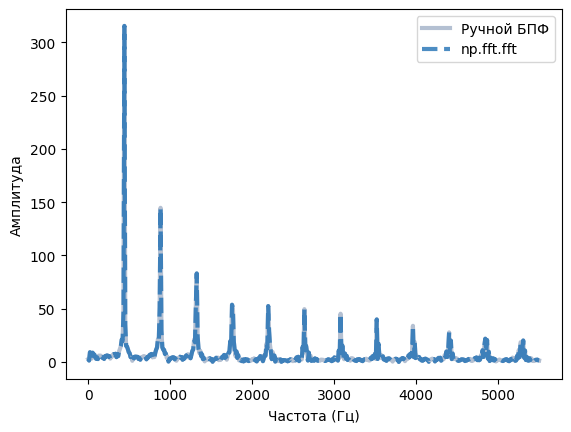

<Figure size 800x600 with 0 Axes>

In [5]:
import numpy as np

def dft_matrix(N):
    """Возвращает матрицу ДПФ размера N x N (комплексную)."""
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return M

def dft_direct(ys):
    """Прямое ДПФ через умножение матрицы (O(N^2))."""
    N = len(ys)
    M = dft_matrix(N)
    return M @ ys

def fft(ys):
    """
    Быстрое преобразование Фурье (рекурсивная реализация).
    Работает для N = степени 2.
    """
    N = len(ys)
    # Базовый случай: при N <= 32 используем прямое ДПФ
    if N <= 32:
        return dft_direct(ys)
    # Убедимся, что N чётное (для простоты требуем степень 2)
    if N % 2 != 0:
        raise ValueError("N должно быть степенью 2")
    # Разделяем на чётные и нечётные элементы
    even = fft(ys[0::2])
    odd = fft(ys[1::2])
    # Объединяем по формуле Дэниелсона-Ланцоша
    factor = np.exp(-2j * np.pi * np.arange(N) / N)
    # Первые N/2 элементов
    half = N // 2
    left = even + factor[:half] * odd
    right = even + factor[half:] * odd
    return np.concatenate([left, right])

# Проверка корректности на случайном сигнале
N = 64
ys = np.random.randn(N) + 1j * np.random.randn(N)
fft_result = fft(ys)
npfft_result = np.fft.fft(ys)
# Сравнение результатов (должно быть очень близко)
print("Максимальная разница между FFT и np.fft.fft:", np.max(np.abs(fft_result - npfft_result)))

# Применение к реальному сигналу
signal = thinkdsp.SawtoothSignal(freq=440)
wave = signal.make_wave(duration=0.1, framerate=11025)
# Берём первые 1024 отсчёта (степень 2)
ys = wave.ys[:1024]
fft_manual = fft(ys)
fft_numpy = np.fft.fft(ys)
# Построим амплитудные спектры
freqs = np.fft.fftfreq(len(ys), d=1/wave.framerate)

thinkplot.plot(freqs[:512], np.abs(fft_manual[:512]), label='Ручной БПФ', alpha = 0.3)
thinkplot.plot(freqs[:512], np.abs(fft_numpy[:512]), '--', label='np.fft.fft', alpha = 0.8)
thinkplot.config(xlabel='Частота (Гц)', ylabel='Амплитуда')
thinkplot.show()